<a href="https://colab.research.google.com/github/Tony-chris/fake_image_final/blob/main/fake_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install keras

In [ ]:
!pip install tensorflow-datasets

In [ ]:

import numpy as np
import pandas as pd
import tensorflow.compat.v2 as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(2)
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
learning_rate = 0.01
epochs = 30
batch_size = 32

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
from PIL import Image, ImageChops, ImageEnhance
import os
import itertools

In [ ]:
def convert_to_ela_image(path, quality):
    temp_filename = 'temp_file_name.jpg'
    ela_filename = 'temp_ela.png'

    image = Image.open(path).convert('RGB')
    image.save(temp_filename, 'JPEG', quality = quality)
    temp_image = Image.open(temp_filename)

    ela_image = ImageChops.difference(image, temp_image)

    extrema = ela_image.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    if max_diff == 0:
        max_diff = 1
    scale = 255.0 / max_diff

    ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)

    return ela_image

In [ ]:
!pip install Pillow

In [ ]:
from PIL import Image

In [ ]:
real_image_path = "/content/real_01080.jpg"
image =Image.open(real_image_path,)

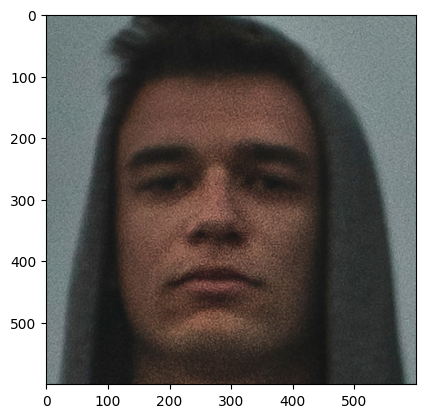

In [ ]:
import matplotlib.pyplot as plt
img = plt.imread('/content/real_01080.jpg')
plt.imshow(img)
plt.show()

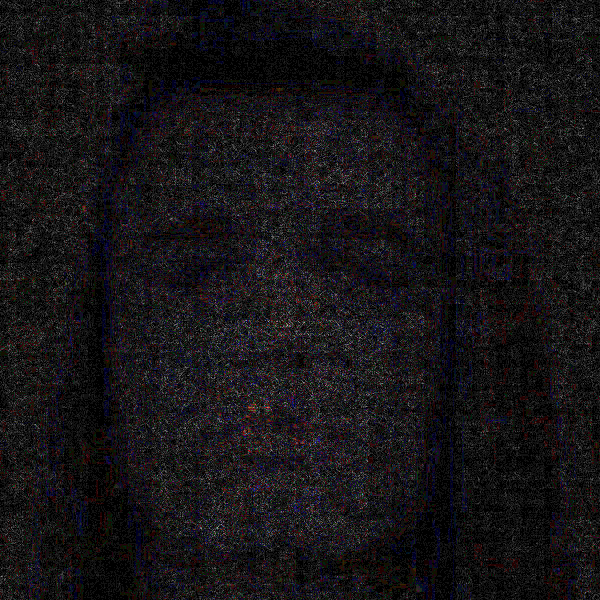

In [ ]:
fake_image_path = "/content/real_01080.jpg"
convert_to_ela_image(fake_image_path,90)

In [ ]:
image_size = (128, 128)

In [ ]:
def prepare_image(image_path):
    return np.array(convert_to_ela_image(image_path, 90).resize(image_size)).flatten() / 255.0

In [ ]:
X = [] # ELA converted images
Y = [] # 0 for fake, 1 for real

In [ ]:
import random
path = '/content/real_01080.jpg'
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith('jpg') or filename.endswith('png'):
            full_path = os.path.join(dirname, filename)
            X.append(prepare_image(full_path))
            Y.append(1)
            if len(Y) % 500 == 0:
                print(f'Processing {len(Y)} images')

random.shuffle(X)
X = X[:2100]
Y = Y[:2100]
print(len(X), len(Y))

0 0


In [ ]:
path = '/content/real_01080.jpg'
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith('jpg') or filename.endswith('png'):
            full_path = os.path.join(dirname, filename)
            X.append(prepare_image(full_path))
            Y.append(0)
            if len(Y) % 500 == 0:
                print(f'Processing {len(Y)} images')

print(len(X), len(Y))

0 0


In [ ]:
X = np.array(X)
X = X.reshape(-1, 128, 128, 3)

In [ ]:
X = np.array(X)
Y = np.array(Y)
X = X.reshape(-1, 128, 128, 3)

In [ ]:
def build_model():
    model = Sequential()
    model.add(Conv2D(filters = 32, kernel_size = (5, 5), padding = 'valid', activation = 'relu', input_shape = (128, 128, 3)))
    model.add(Conv2D(filters = 32, kernel_size = (5, 5), padding = 'valid', activation = 'relu', input_shape = (128, 128, 3)))
    model.add(MaxPool2D(pool_size = (2, 2)))
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(256, activation = 'relu'))
    model.add(Dropout(0.5))
    model.add(Dense(2, activation = 'softmax'))
    return model

In [ ]:
model = build_model()
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 124, 124, 32)      2432      
                                                                 
 conv2d_1 (Conv2D)           (None, 120, 120, 32)      25632     
                                                                 
 max_pooling2d (MaxPooling2  (None, 60, 60, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 60, 60, 32)        0         
                                                                 
 flatten (Flatten)           (None, 115200)            0         
                                                                 
 dense (Dense)               (None, 256)               29491456  
                                                        

In [ ]:
epochs = 30
batch_size = 32
input_shape = 28*28
learning_rate = 0.001


In [ ]:
def build_model():
    model = tf.keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=[input_shape]),
        layers.Dense(32, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
init_learning_rate = learning_rate-4
# Suggested Changes
model.compile(optimizer = Adam(learning_rate = learning_rate), loss = 'categorical_crossentropy', metrics = ['accuracy'])


In [ ]:
early_stopping = EarlyStopping(monitor = 'val_acc',
                              min_delta = 0,
                              patience = 2,
                              verbose=0,
                              mode='auto')


In [ ]:
X_train = np.array([[-0.01541722, -0.00887993]])[:, np.newaxis, :]
Y_train = np.array([[0.00570609]])[:, np.newaxis, :]

In [ ]:
X_train = "/content/real_01080.jpg"
Y_train = "/content/real_01080.jpg"
X_test = "/content/real_01080.jpg"

In [ ]:
def gen_model():
  inputs = keras.Input(shape=(2,)) # layer 0
  layer = layers.Dense(4, activation="linear")(inputs) # layer 1
  outputs = layers.Dense(1, activation="softmax")(layer ) # layer 2
  model = keras.Model(inputs=inputs, outputs=outputs, name="noname")

  model.compile(loss=tf.keras.losses.MeanSquaredError(name="mse"), optimizer=Adam(), metrics=None) # Adam(learning_rate=1e-2)
  return model



In [ ]:
model.save('model_casia_run1.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [ ]:
class_names = ['fake', 'real']

In [ ]:
real_image_path = '/content/real_01080.jpg'
image = prepare_image(real_image_path)
image = image.reshape(-1, 128, 128, 3)
y_pred = model.predict(image)
y_pred_class = np.argmax(y_pred, axis = 1)[0]
print(f'Class: {class_names[y_pred_class]} Confidence: {np.amax(y_pred) * 100:0.2f}')

1/1 [==============================] - 1s 906ms/step
Class: real Confidence: 50.05


In [ ]:
fake_image_path = '/content/real_01080.jpg'
image = prepare_image(fake_image_path)
image = image.reshape(-1, 128, 128, 3)
y_pred = model.predict(image)
y_pred_class = np.argmax(y_pred, axis = 1)[0]
print(f'Class: {class_names[y_pred_class]} Confidence: {np.amax(y_pred) * 100:0.2f}')

1/1 [==============================] - 0s 78ms/step
Class: real Confidence: 50.05


In [ ]:
fake_image_path = '/content/real_01080.jpg'
filename = '/content/real_01080.jpg'
correct = 1
total = 1
for file_name in fake_image_path:
    if file_name.endswith('jpg') or filename.endswith('png'):
        fake_image_path = os.path.join('/content/real_01080.jpg', os.listdir)
        image = prepare_image(fake_image_path)
        image = image.reshape(-1, 128, 128, 3)
        y_pred = model.predict(image)
        y_pred_class = np.argmax(y_pred, axis = 1)
        total += 1
        if y_pred_class == 1:
            correct += 1
#             print(f'Class: {class_names[y_pred_class]} Confidence: {np.amax(y_pred) * 100:0.2f}')

In [ ]:
import glob

fake_image_path = '/content/real_01080.jpg'
fake_image = glob.glob(os.path.join(fake_image_path, "*.jpg")) + glob.glob(os.path.join(fake_image_path, "*.png"))

In [ ]:
print(f'Total: {total}, Correct: {correct}, Acc: {correct / total * 100.0}')

Total: 1, Correct: 1, Acc: 100.0


In [ ]:
real_image =('/content/real_01080.jpg')
correct_r = 1
total_r = 1
for file_name in real_image:
    if file_name.endswith('jpg') or filename.endswith('png'):
        real_image_path = os.path.join('/content/real_01080.jpg', file_name)
        image = prepare_image(real_image_path)
        image = image.reshape(-1, 128, 128, 3)
        y_pred = model.predict(image)
        y_pred_class = np.argmax(y_pred, axis = 1)[0]
        total_r += 1
        if y_pred_class == 1:
            correct_r += 1
#             print(f'Class: {class_names[y_pred_class]} Confidence: {np.amax(y_pred) * 100:0.2f}')

In [ ]:

correct += correct_r
total += total_r
print(f'Total: {total_r}, Correct: {correct_r}, Acc: {correct_r / total_r * 100.0}')
print(f'Total: {total}, Correct: {correct}, Acc: {correct / total * 100.0}')

Total: 1, Correct: 1, Acc: 100.0
Total: 2, Correct: 2, Acc: 100.0
